# CNN from scratch vs Transfert Learning (Cats vs Dogs)

## 1. Configuration et reproductibilité


1.1 Montage du Drive et dossier de travail

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/cnn_cat_dog_image_classification/cnn_cat_dog_image_classification/

/content/drive/MyDrive/cnn_cat_dog_image_classification/cnn_cat_dog_image_classification


###Copie des données en local

In [3]:
%matplotlib inline

import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models



###verfication de GPU

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

## 2. Préparation des données

### 2.1 Copie des données en local et vérification de la structure du dataset

In [6]:
!cp -r Cat_Dog_data /content/

In [7]:
!ls Cat_Dog_data

test  train


In [8]:
%ls Cat_Dog_data/train
%ls Cat_Dog_data/test
!ls /content/Cat_Dog_data/train/cat | wc -l
!ls /content/Cat_Dog_data/train/dog | wc -l
!ls /content/Cat_Dog_data/test/cat | wc -l
!ls /content/Cat_Dog_data/test/dog | wc -l

cat/  dog/
cat/  dog/
11275
11250
1250
1250


Les classes sont équilibrées. 11 275 chats contre 11 250 chiens à l'entraînement, 1 250 contre 1 250 au test

### 2.2 Transformations (train avec augmentation, val/test sans)

In [9]:
# Valeurs de normalisation ImageNet
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Transformations pour l'entraînement (avec augmentation)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Transformations pour la validation et le test (sans augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

### 2.3 Chargement et découpage train / validation

In [10]:
DATA_DIR = "/content/Cat_Dog_data"

full_train_aug = datasets.ImageFolder(DATA_DIR + "/train", transform=train_transform)
full_train_plain = datasets.ImageFolder(DATA_DIR + "/train", transform=val_test_transform)
test_data = datasets.ImageFolder(DATA_DIR + "/test", transform=val_test_transform)

val_size = int(0.2 * len(full_train_aug))
train_size = len(full_train_aug) - val_size

generator = torch.Generator().manual_seed(SEED)
train_data, _ = random_split(full_train_aug, [train_size, val_size], generator=generator)

generator = torch.Generator().manual_seed(SEED)
_, val_data = random_split(full_train_plain, [train_size, val_size], generator=generator)

In [11]:
print(f"Train : {len(train_data)}")
print(f"Validation : {len(val_data)}")
print(f"Test : {len(test_data)}")
print(f"Classes : {full_train_aug.class_to_idx}")

Train : 18020
Validation : 4505
Test : 2500
Classes : {'cat': 0, 'dog': 1}


### 2.4 DataLoaders

In [12]:
#Les DataLoaders
trainloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
valloader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
testloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [13]:
images, labels = next(iter(trainloader))
print(images.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
tensor([0, 1, 0, 1, 0, 1, 0, 0, 0, 0])


In [14]:
def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()

    image = image.numpy().transpose((1, 2, 0))

    if normalize:
        image = np.array(STD) * image + np.array(MEAN)
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

### 2.5 Visualisation d'exemples d'entraînement

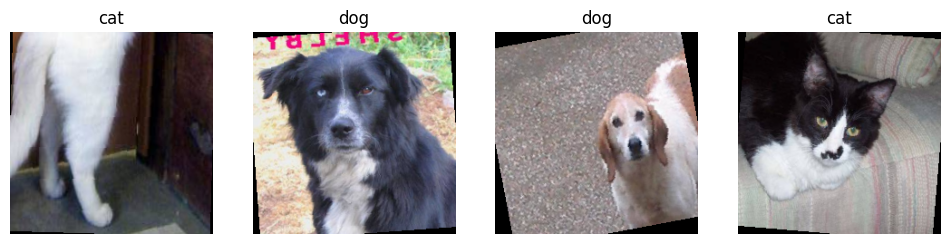

In [15]:
images, labels = next(iter(trainloader))

fig, axes = plt.subplots(figsize=(12, 4), ncols=4)
for i in range(4):
    ax = axes[i]
    imshow(images[i], ax=ax, normalize=True)
    ax.set_title(full_train_aug.classes[labels[i]])

## 3. Moteur d'entraînement

### 3.1 Fonction d'entraînement (train_one_epoch)

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

### 3.2 Fonction d'évaluation (evaluate)

In [17]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    val_loss = running_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    return val_loss, accuracy, precision, recall

### 3.3 Sauvegarde et rechargement des checkpoints

In [18]:
def save_checkpoint(model, optimizer, epoch, history, best_val_acc, path):
    checkpoint = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "epoch": epoch,
        "history": history,
        "best_val_acc": best_val_acc
    }
    # Écriture atomique : fichier temporaire puis renommage instantané
    tmp_path = path + ".tmp"
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)

    # Historique seul, léger, écrit sur Drive à chaque epoch
    light = {"epoch": epoch, "history": history, "best_val_acc": best_val_acc}
    light_path = "checkpoints/" + os.path.basename(path).replace(".pth", "_history.pth")
    tmp_light = light_path + ".tmp"
    torch.save(light, tmp_light)
    os.replace(tmp_light, light_path)

In [19]:
CKPT_DIR = "/content/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

In [20]:
def load_checkpoint(model, optimizer, path, device):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_prec": [],
        "val_rec": []
    }

    if not os.path.exists(path):
        print("Aucun checkpoint trouvé, démarrage à zéro.")
        return 0, history, 0.0

    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    epoch = checkpoint["epoch"] + 1
    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]

    print(f"Checkpoint chargé, reprise à l'epoch {epoch + 1}.")
    return epoch, history, best_val_acc

### 3.4 Boucle d'entraînement complète (train_model)


In [21]:
def train_model(model, trainloader, valloader, criterion, optimizer, device,
                epochs, ckpt_last, ckpt_best, scheduler=None):

    start_epoch, history, best_val_acc = load_checkpoint(model, optimizer, ckpt_last, device)

    for epoch in range(start_epoch, epochs):

        train_loss = train_one_epoch(model, trainloader, criterion, optimizer, device)

        val_loss, val_acc, val_prec, val_rec = evaluate(model, valloader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_prec"].append(val_prec)
        history["val_rec"].append(val_rec)

        save_checkpoint(model, optimizer, epoch, history, best_val_acc, ckpt_last)
        if (epoch + 1) % 3 == 0:
            os.system(f"cp {ckpt_last} checkpoints/")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(model, optimizer, epoch, history, best_val_acc, ckpt_best)
            os.system(f"cp {ckpt_best} checkpoints/")

        # Réduction du learning rate selon la règle du scheduler
        if scheduler is not None:
            scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | lr {optimizer.param_groups[0]['lr']:.5f} | "
              f"train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
              f"acc {val_acc:.4f} | prec {val_prec:.4f} | rec {val_rec:.4f}")

    return history

## 4. Modèle A : CNN from scratch

### 4.1 Architecture et justification de BatchNorm et Dropout


In [26]:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # Bloc 1 : convolution de 32 filtres 3x3, stride=1, padding=1
        # input = 224*224*3 --> output = 224*224*32
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size =3, stride=1, padding=1)
        self.batchnorm1 = nn.BatchNorm2d(32) # recentre les sorties avant la ReLU
        self.relu1 = nn.ReLU()
        # max pooling 2x2, pas de 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # output = 112*112*32

        # Bloc 2 : convolution de 64 filtres 3x3
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.batchnorm2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output = 56*56*64

        # Bloc 3 : convolution de 128 filtres 3x3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.batchnorm3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # output = 28*28*128

        # aplatissons la derniere sortie
        self.flatten = nn.Flatten()           # 28*28*128 = 100352
        # couche linear de 512 neurones
        self.fc1 = nn.Linear(128*28*28, 512)
        self.relu4 = nn.ReLU()
        # coupons aleatoirement la moitie des connexions
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.batchnorm2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.batchnorm3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x


### 4.2 Vérification des dimensions et du nombre de paramètres


In [23]:
model_a = ScratchCNN().to(device)

images, labels = next(iter(trainloader))
images = images.to(device)

outputs = model_a(images)
print(outputs.shape)

torch.Size([32, 2])


In [24]:
print(sum(p.numel() for p in model_a.parameters()))

51475458


##explications
**BatchNorm : où et pourquoi**

Après chaque convolution, avant la ReLU. Elle recentre les sorties de la
convolution, ce qui stabilise l'apprentissage et permet un learning rate
plus élevé sans divergence.

**Dropout : où et pourquoi**

Uniquement dans le classifieur, après la première couche Linear. Sur les
51 475 458 paramètres du réseau, plus de 99 % se trouvent dans fc1. Le
risque de surapprentissage est concentré là. Les blocs convolutifs sont
déjà régularisés par le partage de poids et par la BatchNorm.

In [ ]:
##!rm -f checkpoints/scratch_adam_last.pth checkpoints/scratch_adam_best.pth

### 4.3 Entraînement avec Adam (lr 0.001 puis 0.0001)


In [ ]:
%%time

EPOCHS = 15

model_a_adam_lr1e4 = ScratchCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_adam_lr1e4 = optim.Adam(model_a_adam_lr1e4.parameters(), lr=0.0001)

history_a_adam_lr1e4 = train_model(
    model_a_adam_lr1e4, trainloader, valloader, criterion, optimizer_adam_lr1e4, device,
    epochs=EPOCHS,
    ckpt_last=f"{CKPT_DIR}/scratch_adam_lr1e4_last.pth",
    ckpt_best=f"{CKPT_DIR}/scratch_adam_lr1e4_best.pth"
)

Aucun checkpoint trouvé, démarrage à zéro.
Epoch 1/15 | train_loss 0.6942 | val_loss 0.5773 | acc 0.7012 | prec 0.7019 | rec 0.7012
Epoch 2/15 | train_loss 0.6212 | val_loss 0.5672 | acc 0.7212 | prec 0.7227 | rec 0.7212
Epoch 3/15 | train_loss 0.6024 | val_loss 0.5356 | acc 0.7216 | prec 0.7245 | rec 0.7216
Epoch 4/15 | train_loss 0.5819 | val_loss 0.5158 | acc 0.7325 | prec 0.7538 | rec 0.7325
Epoch 5/15 | train_loss 0.5686 | val_loss 0.4849 | acc 0.7780 | prec 0.7781 | rec 0.7780
Epoch 6/15 | train_loss 0.5657 | val_loss 0.4655 | acc 0.7809 | prec 0.7844 | rec 0.7809
Epoch 7/15 | train_loss 0.5550 | val_loss 0.4806 | acc 0.7680 | prec 0.7777 | rec 0.7680
Epoch 8/15 | train_loss 0.5502 | val_loss 0.4581 | acc 0.7960 | prec 0.8028 | rec 0.7960
Epoch 9/15 | train_loss 0.5403 | val_loss 0.4481 | acc 0.7951 | prec 0.7957 | rec 0.7951
Epoch 10/15 | train_loss 0.5434 | val_loss 0.4398 | acc 0.7969 | prec 0.8006 | rec 0.7969
Epoch 11/15 | train_loss 0.5363 | val_loss 0.4310 | acc 0.8033 | p

In [ ]:
!ls -lh checkpoints/

total 2.4G
-rw------- 1 root root 590M Sep 18 19:35 scratch_adam_best.pth
-rw------- 1 root root 590M Sep 18 19:41 scratch_adam_last.pth
-rw------- 1 root root 590M Sep 18 21:25 scratch_adam_lr1e4_best.pth
-rw------- 1 root root 590M Sep 18 21:26 scratch_adam_lr1e4_last.pth


In [ ]:
!cp /content/checkpoints/*.pth checkpoints/

cp: cannot stat '/content/checkpoints/*.pth': No such file or directory


In [ ]:
##!rm -f /content/checkpoints/scratch_sgd_last.pth /content/checkpoints/scratch_sgd_best.pth

### 4.4 Entraînement avec SGD (lr 0.01 puis 0.001)


In [ ]:
%%time

EPOCHS = 15

model_a_sgd = ScratchCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_sgd = optim.SGD(model_a_sgd.parameters(), lr=0.001, momentum=0.9)

history_a_sgd = train_model(
    model_a_sgd, trainloader, valloader, criterion, optimizer_sgd, device,
    epochs=EPOCHS,
    ckpt_last=f"{CKPT_DIR}/scratch_sgd_lr1e3_last.pth",
    ckpt_best=f"{CKPT_DIR}/scratch_sgd_lr1e3_best.pth"
)

Aucun checkpoint trouvé, démarrage à zéro.
Epoch 1/15 | train_loss 0.6744 | val_loss 0.6315 | acc 0.6513 | prec 0.6559 | rec 0.6513
Epoch 2/15 | train_loss 0.6478 | val_loss 0.6114 | acc 0.6646 | prec 0.6679 | rec 0.6646
Epoch 3/15 | train_loss 0.6367 | val_loss 0.5973 | acc 0.7021 | prec 0.7022 | rec 0.7021
Epoch 4/15 | train_loss 0.6288 | val_loss 0.5779 | acc 0.6812 | prec 0.6918 | rec 0.6812
Epoch 5/15 | train_loss 0.6165 | val_loss 0.5689 | acc 0.7223 | prec 0.7251 | rec 0.7223
Epoch 6/15 | train_loss 0.6096 | val_loss 0.5383 | acc 0.7310 | prec 0.7345 | rec 0.7310
Epoch 7/15 | train_loss 0.5980 | val_loss 0.5242 | acc 0.7374 | prec 0.7374 | rec 0.7374
Epoch 8/15 | train_loss 0.5925 | val_loss 0.4982 | acc 0.7574 | prec 0.7581 | rec 0.7574
Epoch 9/15 | train_loss 0.5914 | val_loss 0.5135 | acc 0.7614 | prec 0.7624 | rec 0.7614
Epoch 10/15 | train_loss 0.5795 | val_loss 0.4673 | acc 0.7802 | prec 0.7804 | rec 0.7802
Epoch 11/15 | train_loss 0.5754 | val_loss 0.4852 | acc 0.7640 | p

In [ ]:
!ls -lh checkpoints/

total 3.1G
-rw------- 1 root root 590M Sep 18 19:35 scratch_adam_best.pth
-rw------- 1 root root 590M Sep 18 19:41 scratch_adam_last.pth
-rw------- 1 root root 590M Sep 18 21:25 scratch_adam_lr1e4_best.pth
-rw------- 1 root root 590M Sep 18 21:26 scratch_adam_lr1e4_last.pth
-rw------- 1 root root 2.3K Sep 20 00:39 scratch_sgd_lr1e3_best_history.pth
-rw------- 1 root root 393M Sep 20 00:39 scratch_sgd_lr1e3_best.pth
-rw------- 1 root root 2.3K Sep 20 00:43 scratch_sgd_lr1e3_last_history.pth
-rw------- 1 root root 393M Sep 20 00:43 scratch_sgd_lr1e3_last.pth


In [ ]:
h_adam = torch.load("checkpoints/scratch_adam_lr1e4_last.pth", map_location="cpu")["history"]
h_sgd = torch.load("checkpoints/scratch_sgd_lr1e3_last_history.pth", map_location="cpu")["history"]

### 4.5 Comparaison des optimiseurs (tableau, courbes, analyse)


### Comparaison des optimiseurs – Modèle A

| Optimiseur         | Learning rate | Accuracy finale | Val loss finale | Observation                      |
| ------------------ | ------------: | --------------: | --------------: | -------------------------------- |
| Adam               |         0.001 |           0.609 |           0.652 | Apprentissage bloqué             |
| Adam               |        0.0001 |       **0.823** |       **0.410** | Meilleur résultat                |
| SGD (momentum 0.9) |          0.01 |           0.502 |           0.693 | Prédit une seule classe          |
| SGD (momentum 0.9) |         0.001 |           0.782 |           0.500 | Convergence lente mais régulière |

Les deux optimiseurs ont d'abord été testés à leur valeur usuelle (0.001 pour Adam, 0.01 pour SGD) et les deux ont échoué. En divisant le learning rate par dix, l'apprentissage devient stable dans les deux cas. Cette sensibilité s'explique par l'architecture : plus de 99 % des 51 millions de paramètres sont concentrés dans la couche `fc1`.

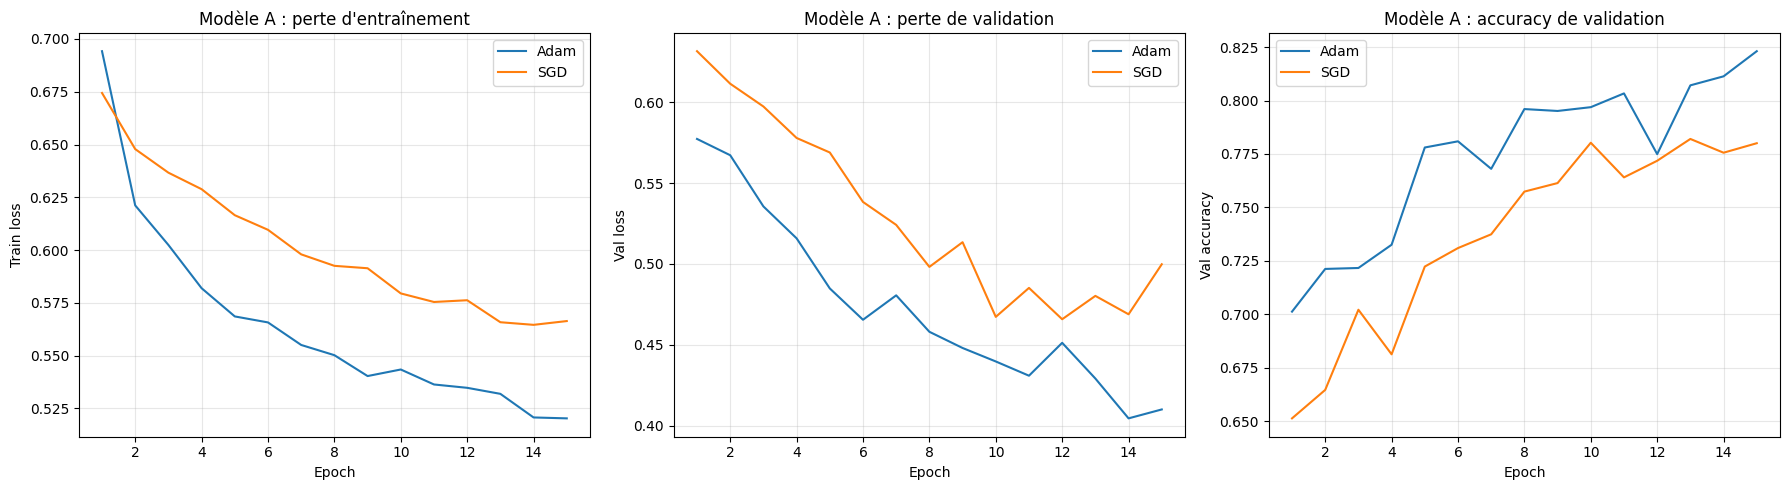

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, 16)

# Perte d'entraînement
axes[0].plot(epochs, h_adam["train_loss"], label="Adam")
axes[0].plot(epochs, h_sgd["train_loss"], label="SGD")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train loss")
axes[0].set_title("Modèle A : perte d'entraînement")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Perte de validation
axes[1].plot(epochs, h_adam["val_loss"], label="Adam")
axes[1].plot(epochs, h_sgd["val_loss"], label="SGD")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val loss")
axes[1].set_title("Modèle A : perte de validation")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Accuracy de validation
axes[2].plot(epochs, h_adam["val_acc"], label="Adam")
axes[2].plot(epochs, h_sgd["val_acc"], label="SGD")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Val accuracy")
axes[2].set_title("Modèle A : accuracy de validation")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/optimiseurs_a.png", dpi=150, bbox_inches="tight")
plt.show()

Les courbes montrent que Adam donne de meilleurs résultats que SGD. Avec Adam, la perte d'entraînement diminue régulièrement et la validation loss atteint environ 0,41, tandis que l'accuracy de validation monte jusqu'à 82,3 %.

SGD progresse également, mais plus lentement et avec davantage de variations. Il termine autour de 78 % d'accuracy et une validation loss d'environ 0,50. Sa validation loss remonte même légèrement sur les trois dernières epochs alors que sa perte d'entraînement continue de baisser, premier signe de surapprentissage. C'est ce qui justifie de sauvegarder le meilleur epoch plutôt que le dernier.

On remarque donc qu'Adam converge plus rapidement et atteint une meilleure performance sur cette architecture. Malgré cela, les deux modèles semblent atteindre une limite de performance, ce qui justifie l'utilisation du transfer learning pour la suite.

## 5. Modèle B : transfert learning (ResNet18)

### 5.1 Chargement, gel du backbone et nouvelle tête


In [ ]:
model_b = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print("Tête d'origine:")
print(model_b.fc)

for param in model_b.parameters():
    param.requires_grad = False

model_b.fc = nn.Linear(model_b.fc.in_features, 2)
print("\nTête remplacée (2 classes) :")
print(model_b.fc)

model_b = model_b.to(device)

entrainables = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_b.parameters())
print(f"\nParamètres entraînables : {entrainables:,} sur {total:,}")

Tête d'origine:
Linear(in_features=512, out_features=1000, bias=True)

Tête remplacée (2 classes) :
Linear(in_features=512, out_features=2, bias=True)

Paramètres entraînables : 1,026 sur 11,177,538


In [ ]:
for nom, param in model_b.named_parameters():
    if param.requires_grad:
        print(nom)

fc.weight
fc.bias


### 5.2 Entraînement avec Adam

In [ ]:
%%time

EPOCHS = 15

criterion = nn.CrossEntropyLoss()
optimizer_b_adam = optim.Adam(model_b.parameters(), lr=0.001)

history_b_adam = train_model(
    model_b, trainloader, valloader, criterion, optimizer_b_adam, device,
    epochs=EPOCHS,
    ckpt_last=f"{CKPT_DIR}/resnet_adam_last.pth",
    ckpt_best=f"{CKPT_DIR}/resnet_adam_best.pth"
)

Aucun checkpoint trouvé, démarrage à zéro.
Epoch 1/15 | train_loss 0.2414 | val_loss 0.1042 | acc 0.9556 | prec 0.9585 | rec 0.9556
Epoch 2/15 | train_loss 0.1900 | val_loss 0.0814 | acc 0.9651 | prec 0.9667 | rec 0.9651
Epoch 3/15 | train_loss 0.1940 | val_loss 0.0596 | acc 0.9774 | prec 0.9774 | rec 0.9774
Epoch 4/15 | train_loss 0.1911 | val_loss 0.0625 | acc 0.9723 | prec 0.9728 | rec 0.9723
Epoch 5/15 | train_loss 0.1824 | val_loss 0.0558 | acc 0.9767 | prec 0.9767 | rec 0.9767
Epoch 6/15 | train_loss 0.1838 | val_loss 0.0704 | acc 0.9689 | prec 0.9699 | rec 0.9689
Epoch 7/15 | train_loss 0.1910 | val_loss 0.0570 | acc 0.9796 | prec 0.9797 | rec 0.9796
Epoch 8/15 | train_loss 0.1807 | val_loss 0.0546 | acc 0.9769 | prec 0.9769 | rec 0.9769
Epoch 9/15 | train_loss 0.1763 | val_loss 0.0532 | acc 0.9774 | prec 0.9774 | rec 0.9774
Epoch 10/15 | train_loss 0.1802 | val_loss 0.0557 | acc 0.9785 | prec 0.9786 | rec 0.9785
Epoch 11/15 | train_loss 0.1889 | val_loss 0.0525 | acc 0.9774 | p

In [ ]:
!cp /content/checkpoints/*.pth checkpoints/

### 5.3 Entraînement avec SGD

In [ ]:
%%time

EPOCHS = 15

model_b_sgd = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_b_sgd.parameters():
    param.requires_grad = False
model_b_sgd.fc = nn.Linear(model_b_sgd.fc.in_features, 2)
model_b_sgd = model_b_sgd.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_b_sgd = optim.SGD(model_b_sgd.parameters(), lr=0.01, momentum=0.9)

history_b_sgd = train_model(
    model_b_sgd, trainloader, valloader, criterion, optimizer_b_sgd, device,
    epochs=EPOCHS,
    ckpt_last=f"{CKPT_DIR}/resnet_sgd_last.pth",
    ckpt_best=f"{CKPT_DIR}/resnet_sgd_best.pth"
)

Aucun checkpoint trouvé, démarrage à zéro.
Epoch 1/15 | train_loss 0.3070 | val_loss 0.1216 | acc 0.9583 | prec 0.9609 | rec 0.9583
Epoch 2/15 | train_loss 0.3657 | val_loss 0.2938 | acc 0.9219 | prec 0.9323 | rec 0.9219
Epoch 3/15 | train_loss 0.3416 | val_loss 0.2096 | acc 0.9450 | prec 0.9502 | rec 0.9450
Epoch 4/15 | train_loss 0.3207 | val_loss 0.0862 | acc 0.9725 | prec 0.9732 | rec 0.9725
Epoch 5/15 | train_loss 0.3143 | val_loss 0.0669 | acc 0.9769 | prec 0.9772 | rec 0.9769
Epoch 6/15 | train_loss 0.2915 | val_loss 0.2337 | acc 0.9383 | prec 0.9449 | rec 0.9383
Epoch 7/15 | train_loss 0.3292 | val_loss 0.2051 | acc 0.9450 | prec 0.9501 | rec 0.9450
Epoch 8/15 | train_loss 0.3409 | val_loss 0.0754 | acc 0.9725 | prec 0.9728 | rec 0.9725
Epoch 9/15 | train_loss 0.3146 | val_loss 0.1887 | acc 0.9494 | prec 0.9537 | rec 0.9494
Epoch 10/15 | train_loss 0.3631 | val_loss 0.1253 | acc 0.9676 | prec 0.9690 | rec 0.9676
Epoch 11/15 | train_loss 0.2831 | val_loss 0.0628 | acc 0.9751 | p

In [29]:
criterion = nn.CrossEntropyLoss()

In [30]:
%%time

EPOCHS = 15

model_b_sgd_sched = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_b_sgd_sched.parameters():
    param.requires_grad = False
model_b_sgd_sched.fc = nn.Linear(model_b_sgd_sched.fc.in_features, 2)
model_b_sgd_sched = model_b_sgd_sched.to(device)

optimizer_sched = optim.SGD(model_b_sgd_sched.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer_sched, step_size=5, gamma=0.1)

history_b_sgd_sched = train_model(
    model_b_sgd_sched, trainloader, valloader, criterion, optimizer_sched, device,
    epochs=EPOCHS,
    ckpt_last=f"{CKPT_DIR}/resnet_sgd_sched_last.pth",
    ckpt_best=f"{CKPT_DIR}/resnet_sgd_sched_best.pth",
    scheduler=scheduler
)

Aucun checkpoint trouvé, démarrage à zéro.
Epoch 1/15 | lr 0.01000 | train_loss 0.3177 | val_loss 0.0830 | acc 0.9705 | prec 0.9713 | rec 0.9705
Epoch 2/15 | lr 0.01000 | train_loss 0.3587 | val_loss 0.0877 | acc 0.9720 | prec 0.9729 | rec 0.9720
Epoch 3/15 | lr 0.01000 | train_loss 0.2876 | val_loss 0.2405 | acc 0.9323 | prec 0.9401 | rec 0.9323
Epoch 4/15 | lr 0.01000 | train_loss 0.3126 | val_loss 0.1747 | acc 0.9476 | prec 0.9524 | rec 0.9476
Epoch 5/15 | lr 0.00100 | train_loss 0.3961 | val_loss 0.1143 | acc 0.9685 | prec 0.9696 | rec 0.9685
Epoch 6/15 | lr 0.00100 | train_loss 0.2443 | val_loss 0.0621 | acc 0.9771 | prec 0.9772 | rec 0.9771
Epoch 7/15 | lr 0.00100 | train_loss 0.2161 | val_loss 0.0590 | acc 0.9778 | prec 0.9778 | rec 0.9778
Epoch 8/15 | lr 0.00100 | train_loss 0.2014 | val_loss 0.0613 | acc 0.9765 | prec 0.9767 | rec 0.9765
Epoch 9/15 | lr 0.00100 | train_loss 0.1992 | val_loss 0.0546 | acc 0.9785 | prec 0.9786 | rec 0.9785
Epoch 10/15 | lr 0.00010 | train_loss 0

In [31]:
!cp /content/checkpoints/*.pth checkpoints/

In [ ]:
!cp /content/checkpoints/*.pth checkpoints/
!ls -lh checkpoints/

cp: cannot stat '/content/checkpoints/*.pth': No such file or directory
total 3.3G
-rw------- 1 root root 2.2K Sep 20 01:29 resnet_adam_best_history.pth
-rw------- 1 root root  43M Sep 20 01:29 resnet_adam_best.pth
-rw------- 1 root root 2.3K Sep 20 01:31 resnet_adam_last_history.pth
-rw------- 1 root root  43M Sep 20 01:31 resnet_adam_last.pth
-rw------- 1 root root 2.1K Sep 20 01:56 resnet_sgd_best_history.pth
-rw------- 1 root root  43M Sep 20 01:56 resnet_sgd_best.pth
-rw------- 1 root root 2.3K Sep 20 02:00 resnet_sgd_last_history.pth
-rw------- 1 root root  43M Sep 20 02:00 resnet_sgd_last.pth
-rw------- 1 root root 590M Sep 18 19:35 scratch_adam_best.pth
-rw------- 1 root root 590M Sep 18 19:41 scratch_adam_last.pth
-rw------- 1 root root 590M Sep 18 21:25 scratch_adam_lr1e4_best.pth
-rw------- 1 root root 590M Sep 18 21:26 scratch_adam_lr1e4_last.pth
-rw------- 1 root root 2.3K Sep 20 00:39 scratch_sgd_lr1e3_best_history.pth
-rw------- 1 root root 393M Sep 20 02:02 scratch_sgd_

In [34]:
h_b_adam = torch.load("checkpoints/resnet_adam_last_history.pth", map_location="cpu")["history"]
h_b_sgd = torch.load("checkpoints/resnet_sgd_last_history.pth", map_location="cpu")["history"]

### 5.4 Comparaison des optimiseurs (tableau, courbes, analyse)


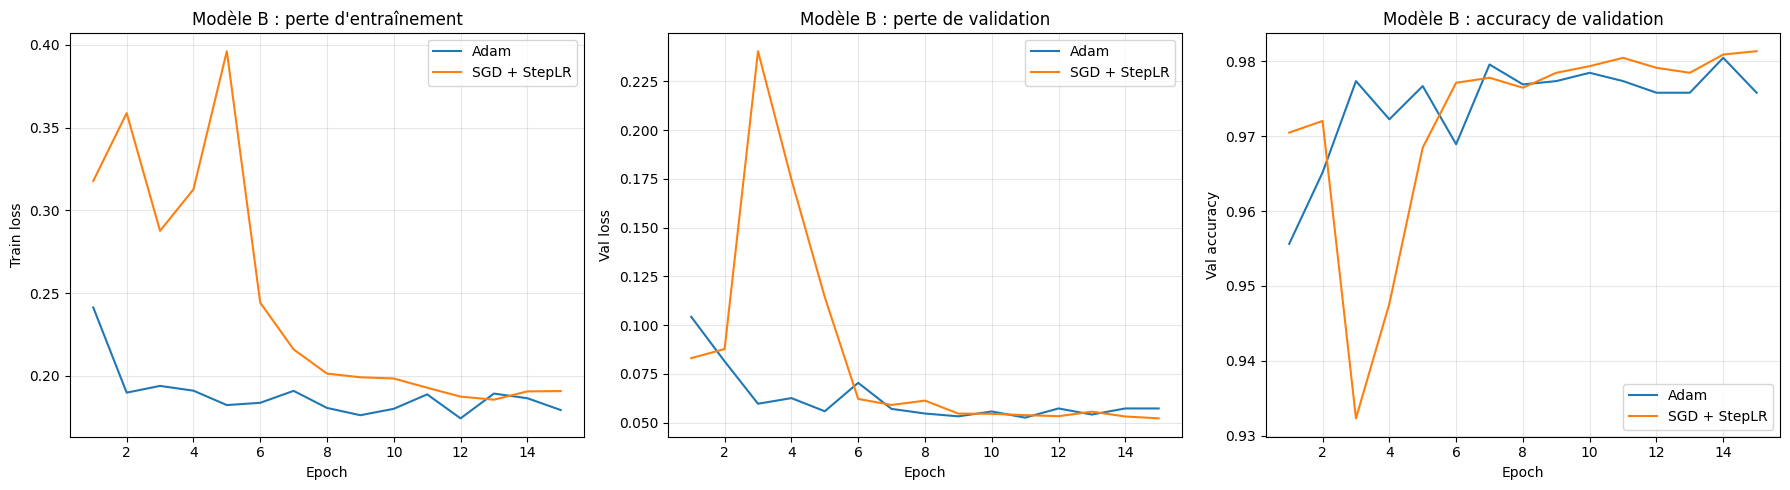

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = range(1, 16)

# Perte d'entraînement
axes[0].plot(epochs, h_b_adam["train_loss"], label="Adam")
axes[0].plot(epochs, h_sched["train_loss"], label="SGD + StepLR")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Train loss")
axes[0].set_title("Modèle B : perte d'entraînement")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Perte de validation
axes[1].plot(epochs, h_b_adam["val_loss"], label="Adam")
axes[1].plot(epochs, h_sched["val_loss"], label="SGD + StepLR")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val loss")
axes[1].set_title("Modèle B : perte de validation")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Accuracy de validation
axes[2].plot(epochs, h_b_adam["val_acc"], label="Adam")
axes[2].plot(epochs, h_sched["val_acc"], label="SGD + StepLR")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Val accuracy")
axes[2].set_title("Modèle B : accuracy de validation")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/optimiseurs_b.png", dpi=150, bbox_inches="tight")
plt.show()

**Comparaison des optimiseurs – Modèle B**
| Optimiseur | Learning rate | Meilleure accuracy | Val loss | Observation |
|---|---|---:|---:|---|
| Adam | 0.001 | 0.981 | 0.057 | Stable dès l'epoch 3 |
| SGD | 0.01 | 0.978 | 0.099 | Fortes oscillations |
| SGD + StepLR | 0.01 → 0.00001 | **0.981** | **0.052** | Instable au début, puis stable dès l'epoch 5 |

Les trois configurations obtiennent de très bonnes performances, avec une accuracy proche de 98 %. Cependant, leur stabilité varie selon l'optimiseur utilisé.

Avec Adam, la perte diminue rapidement et reste relativement stable. L'accuracy de validation se maintient autour de 97–98 %, et le modèle converge rapidement, avec une bonne stabilité dès la troisième epoch.

Avec SGD, les courbes sont plus irrégulières. La validation loss et l'accuracy varient fortement d'une epoch à l'autre, ce qui montre que l'apprentissage est moins stable avec un learning rate de 0,01.

L'ajout du scheduler StepLR améliore le comportement de SGD. Malgré une certaine instabilité au début, le modèle se stabilise à partir de la cinquième epoch. Il atteint une accuracy de 98,1 % et une validation loss de 0,052, contre 97,8 % et 0,099 pour SGD sans scheduler.

En conclusion, Adam et SGD avec StepLR obtiennent des résultats très proches. Adam converge plus rapidement et reste stable dès la troisième epoch, tandis que SGD avec StepLR atteint une validation loss légèrement plus faible après une phase initiale d'instabilité. Ces deux configurations sont donc intéressantes pour la suite.

## 6. Comparaison des deux modèles

In [ ]:
h_a = torch.load("checkpoints/scratch_adam_lr1e4_last.pth", map_location="cpu")["history"]
h_b = torch.load("checkpoints/resnet_adam_last_history.pth", map_location="cpu")["history"]

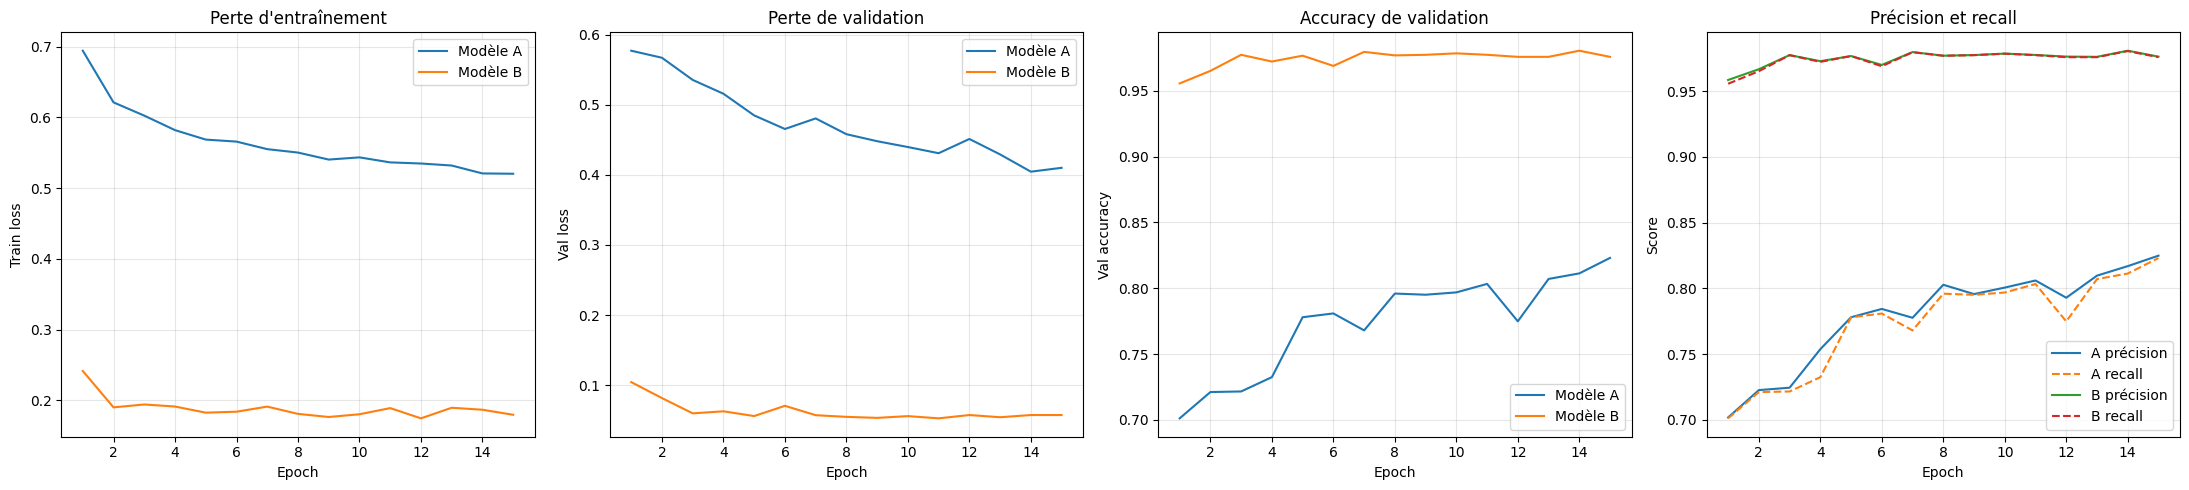

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
epochs = range(1, 16)

# (clé, titre, label de l'axe y)
courbes = [
    ("train_loss", "Perte d'entraînement", "Train loss"),
    ("val_loss",   "Perte de validation",  "Val loss"),
    ("val_acc",    "Accuracy de validation", "Val accuracy"),
]

for ax, (cle, titre, ylabel) in zip(axes, courbes):
    ax.plot(epochs, h_a[cle], label="Modèle A")
    ax.plot(epochs, h_b[cle], label="Modèle B")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(titre)
    ax.legend()
    ax.grid(alpha=0.3)

# Quatrième panneau : précision et recall des deux modèles
axes[3].plot(epochs, h_a["val_prec"], label="A précision")
axes[3].plot(epochs, h_a["val_rec"], label="A recall", linestyle="--")
axes[3].plot(epochs, h_b["val_prec"], label="B précision")
axes[3].plot(epochs, h_b["val_rec"], label="B recall", linestyle="--")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("Score")
axes[3].set_title("Précision et recall")
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Comparaison globale des deux modèles

Les courbes montrent une différence nette entre les deux modèles. Le modèle B atteint rapidement de très bonnes performances : sa perte d'entraînement et sa perte de validation restent faibles, tandis que son accuracy de validation se maintient autour de 97–98 %.

À l'inverse, le modèle A progresse progressivement, mais son accuracy atteint seulement environ 82 % après 15 epochs. Il reste donc nettement en dessous du modèle B.

Sur le quatrième graphique, la précision et le recall se superposent pour chaque modèle. Cela indique que leurs performances sont relativement équilibrées entre les deux classes.

Cette performance est obtenue à un coût bien moindre. Le modèle B n'entraîne que 1 026 paramètres, ceux de sa dernière couche, contre 51 475 458 pour le modèle A entraîné entièrement. Son checkpoint pèse 43 Mo contre 590 Mo, et il converge en 3 epochs là où le modèle A n'a toujours pas fini de progresser après 15.

En résumé, le modèle B converge beaucoup plus rapidement et obtient de meilleures performances que le modèle A. Cette différence s'explique notamment par l'utilisation du transfer learning avec ResNet18, qui permet de partir de représentations déjà apprises sur un grand jeu d'images.

### 7. Test final sur le jeu de test


**Model A**

In [ ]:
criterion = nn.CrossEntropyLoss()

### 7.1 Rechargement et évaluation du modèle A

Le meilleur checkpoint du modèle A (Adam, lr = 0.0001) est rechargé depuis
le disque dans une architecture vide, puis évalué sur les 2 500 images de
test, qui n'ont jamais été utilisées pendant l'entraînement ni pour les
choix d'hyperparamètres.

In [ ]:
model_a_test = ScratchCNN().to(device)
ckpt_a = torch.load("checkpoints/scratch_adam_lr1e4_best.pth", map_location=device)
model_a_test.load_state_dict(ckpt_a["model_state"])

test_loss_a, test_acc_a, test_prec_a, test_rec_a = evaluate(model_a_test, testloader, criterion, device)
print(f"Modèle A | loss {test_loss_a:.4f} | acc {test_acc_a:.4f} | prec {test_prec_a:.4f} | rec {test_rec_a:.4f}")

Modèle A | loss 0.4272 | acc 0.8056 | prec 0.8064 | rec 0.8056


### 7.2 Rechargement et évaluation du modèle B


In [ ]:
model_b_test = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_b_test.fc = nn.Linear(model_b_test.fc.in_features, 2)
model_b_test = model_b_test.to(device)

ckpt_b = torch.load("checkpoints/resnet_adam_best.pth", map_location=device)
model_b_test.load_state_dict(ckpt_b["model_state"])

test_loss_b, test_acc_b, test_prec_b, test_rec_b = evaluate(model_b_test, testloader, criterion, device)
print(f"Modèle B | loss {test_loss_b:.4f} | acc {test_acc_b:.4f} | prec {test_prec_b:.4f} | rec {test_rec_b:.4f}")

Modèle B | loss 0.0567 | acc 0.9776 | prec 0.9779 | rec 0.9776


### 7.3 Synthèse des résultats

| Modèle | Test accuracy | Précision | Recall | Test loss | Paramètres entraînés | Taille du checkpoint |
|---|---:|---:|---:|---:|---:|---:|
| A : CNN from scratch (Adam, lr 0.0001) | 80,6 % | 80,6 % | 80,6 % | 0,427 | 51 475 458 | 590 Mo |
| B : ResNet18 gelé (Adam, lr 0.001) | **97,8 %** | **97,8 %** | **97,8 %** | **0,057** | **1 026** | **43 Mo** |

Le modèle B dépasse le modèle A de 17 points d'accuracy sur le jeu de
test, en n'entraînant que 1 026 paramètres contre plus de 51 millions.
Les deux modèles conservent sur le test un score proche de leur meilleure
validation (82,3 % pour A, 98,1 % pour B), ce qui indique qu'ils
généralisent correctement.

## 8. Analyse

In [ ]:
def get_predictions(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())

    return all_labels, all_preds

### 8.1 Matrices de confusion

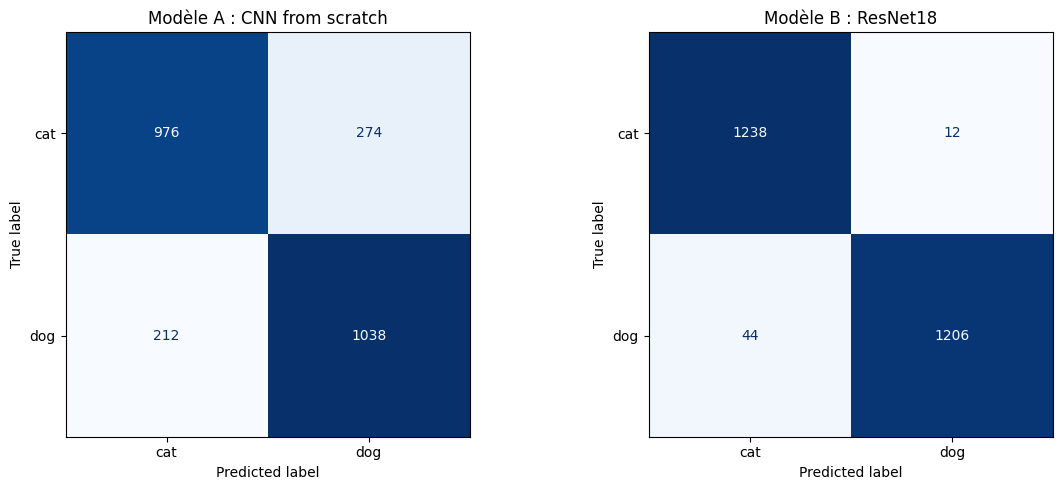

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels_a, preds_a = get_predictions(model_a_test, testloader, device)
labels_b, preds_b = get_predictions(model_b_test, testloader, device)

# Calcul des deux matrices
cm_a = confusion_matrix(labels_a, preds_a)
cm_b = confusion_matrix(labels_b, preds_b)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_a, display_labels=["cat", "dog"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Modèle A : CNN from scratch")

ConfusionMatrixDisplay(cm_b, display_labels=["cat", "dog"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Modèle B : ResNet18")

plt.tight_layout()
plt.savefig("figures/confusion.png", dpi=150, bbox_inches="tight")
plt.show()

***Matrices de confusion – Jeu de test***

Sur les 2 500 images de test, le modèle A fait 486 erreurs : 274 chats sont classés comme chiens et 212 chiens comme chats. Il reconnaît correctement environ 78 % des chats et 83 % des chiens, avec une légère tendance à prédire la classe « chien ».

Le modèle B obtient de meilleurs résultats, avec seulement 56 erreurs. Il reconnaît environ 99 % des chats et 96,5 % des chiens. Les erreurs sont principalement des chiens classés comme chats (44 images), contre seulement 12 chats classés comme chiens.

Ainsi, le modèle B distingue beaucoup mieux les deux classes sur le jeu de test. Les erreurs du modèle A sont plus nombreuses et relativement équilibrées entre les deux classes, tandis que le modèle B présente davantage d'erreurs sur les chiens.

### 8.2 Erreurs typiques et confiance du modèle


In [ ]:
erreurs_b = [i for i in range(len(labels_b)) if labels_b[i] != preds_b[i]]
print(len(erreurs_b))

56


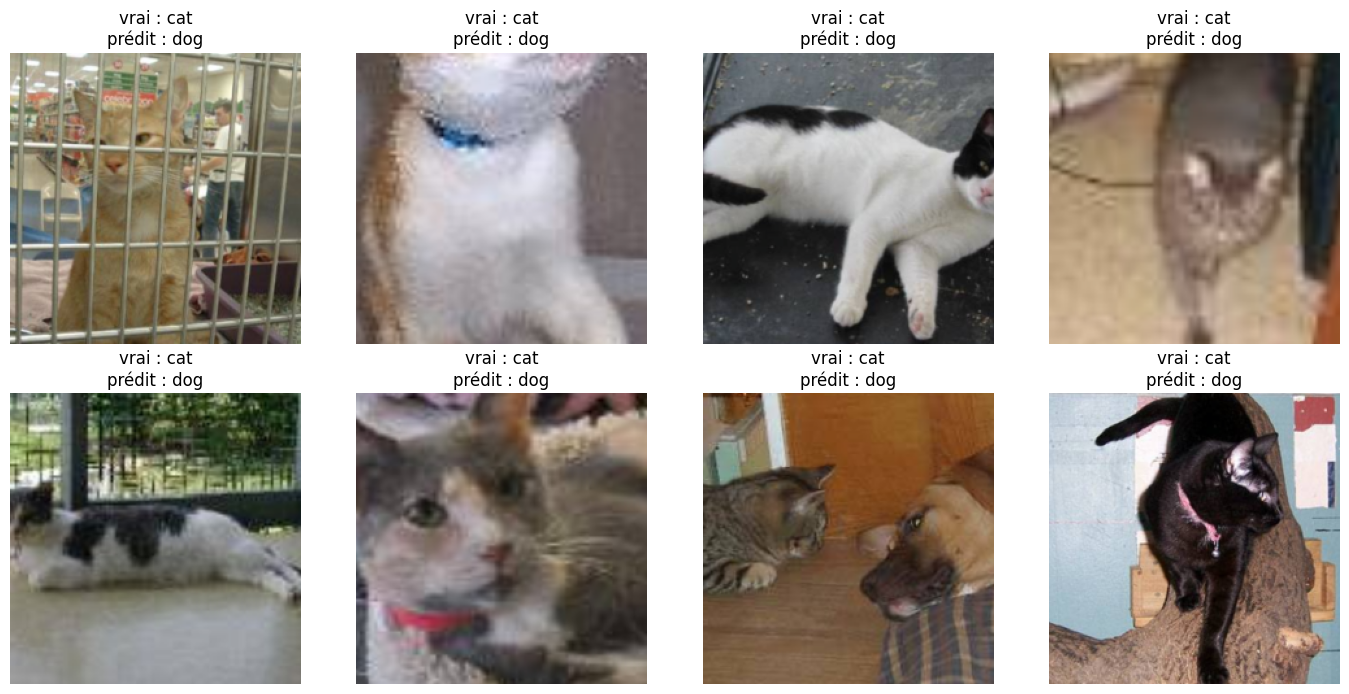

In [ ]:
classes = ["cat", "dog"]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, i in zip(axes.flatten(), erreurs_b[:8]):
    image, _ = test_data[i]
    imshow(image, ax=ax, normalize=True)
    ax.set_title(f"vrai : {classes[labels_b[i]]}\nprédit : {classes[preds_b[i]]}")

plt.tight_layout()
plt.savefig("figures/erreurs.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
image, _ = test_data[erreurs_b[0]]
with torch.no_grad():
    out = model_b_test(image.unsqueeze(0).to(device))
    probas = torch.softmax(out, dim=1)
print(probas)

tensor([[0.3410, 0.6590]], device='cuda:0')


In [ ]:
bonnes, fausses = [], []

model_b_test.eval()
with torch.no_grad():
    for i in range(len(test_data)):
        image, label = test_data[i]
        out = model_b_test(image.unsqueeze(0).to(device))
        confiance = torch.softmax(out, dim=1).max().item()
        if labels_b[i] == preds_b[i]:
            bonnes.append(confiance)
        else:
            fausses.append(confiance)

print(f"Confiance moyenne sur les bonnes réponses : {np.mean(bonnes):.3f}")
print(f"Confiance moyenne sur les erreurs         : {np.mean(fausses):.3f}")

Confiance moyenne sur les bonnes réponses : 0.980
Confiance moyenne sur les erreurs         : 0.729


***Erreurs typiques du modèle B**

Les erreurs du modèle B apparaissent surtout sur des images difficiles à interpréter : visage caché par des barreaux, tête coupée par le recadrage, image floue ou présence des deux animaux.

Certains chats mal classés portent également un collier, ce qui pourrait avoir influencé la prédiction, mais cette observation reste à confirmer avec davantage d'exemples.

La confiance du modèle est en moyenne de 98 % pour les bonnes prédictions, contre 73 % pour les erreurs. Cela montre que le modèle est généralement moins sûr lorsqu'il se trompe, même si certaines erreurs sont faites avec une confiance élevée.

## 9. Conclusion et limites

### Conclusion

Ce projet a permis de comparer deux approches pour la classification d'images de chats et de chiens : un CNN entraîné à partir de zéro et un ResNet18 pré-entraîné, dont seule la dernière couche a été entraînée.

Sur les 2 500 images de test, le modèle B obtient 97,8 % d'accuracy, contre 80,6 % pour le modèle A, soit une différence de 17,2 points de pourcentage. Le modèle B atteint également de bonnes performances beaucoup plus rapidement, tout en n'entraînant que 1 026 paramètres, contre plus de 51 millions pour le modèle A.

Ces résultats montrent que, pour un jeu de données de taille modérée, le transfer learning est particulièrement efficace. Le modèle bénéficie de représentations déjà apprises sur un grand ensemble d'images, ce qui lui permet d'obtenir de bonnes performances sans devoir tout apprendre à partir de zéro.

La recherche du learning rate a également montré son importance, puisque des valeurs trop élevées pouvaient entraîner une instabilité et de mauvaises performances.

### Limites et pistes d'amélioration

Le modèle A possède une architecture assez lourde, avec plus de 99 % de ses paramètres concentrés dans la couche `fc1`. L'utilisation d'un `AdaptiveAvgPool2d` permettrait de réduire considérablement le nombre de paramètres et de rendre le modèle plus léger.

Le modèle A progressait encore après 15 epochs. Un entraînement plus long pourrait donc améliorer ses performances.

Pour SGD, le learning rate de 0,01 provoque des oscillations importantes avec le modèle B. Un learning rate plus faible ou l'utilisation d'un scheduler pourrait rendre l'apprentissage plus stable.

Enfin, seul le feature extraction a été testé avec ResNet18. Ce choix s'expliquait par la taille modérée du jeu de données et sa proximité avec le domaine d'ImageNet. Une prochaine expérience pourrait consister à dégeler les dernières couches du réseau et à les entraîner avec un learning rate plus faible afin d'évaluer l'intérêt du fine-tuning.